# Peramalan kadar $NO_2$ di daerah Surabaya



## Latar Belakang

Peningkatan aktivitas industri, transportasi, serta pertumbuhan populasi dapat menyebabkan peningkatan pencemaran udara. Salah satu polutan udara yang penting untuk dianalisis adalah Nitrogen Dioksida (NO₂), yaitu gas yang banyak dihasilkan dari proses pembakaran bahan bakar fosil seperti kendaraan bermotor, pembangkit listrik, dan kegiatan industri.

Notebook ini mengambil data NO₂ menggunakan **OpenEO Copernicus Dataspace**, kemudian melakukan preprocessing, interpolasi missing value, deteksi outlier IQR, dan modelling menggunakan KNN Regression.


## 1. Pengumpulan Data

Kita install terlebih dahulu `openeo`:

In [4]:
pip install openeo

Lalu tuliskan code dibawah:

In [3]:
import openeo

connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=XJTE-MBWY 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.


In [6]:
aoi = {
    "type": "Polygon",
    "coordinates": [
        [
            [112.84, -7.15],
            [112.55, -7.15],
            [112.55, -7.35],
            [112.84, -7.35],
            [112.84, -7.15],
        ]
    ]
}

s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2024-10-01", "2026-06-03"],
    spatial_extent={
        "west": 112.55,
        "south": -7.35,
        "east": 112.84,
        "north": -7.15
    },
    bands=["NO2"],
)

# Now aggregate by day to avoid having multiple data per day
s5p_no2_daily = s5post.aggregate_temporal_period(reducer="mean", period="day")

# Now create a spatial aggregation to generate mean timeseries data
s5p_no2_aoi = s5p_no2_daily.aggregate_spatial(reducer="mean", geometries=aoi)

Di panel sebelah kanan terdapat data JSON yang berupa koordinat daerah yang kalian pilih. Salin koordinat tersebut, lalu sesuaikan dengan code di atas pada bagian variabel `aoi` dan `spatial_extent`.

Lalu tambahkan baris code di bawah untuk memulai pengambilan data:


In [8]:
job = s5post.execute_batch(title="NO2 in Surabaya terkini", outputfile="NO2Surabaya Terkini.nc")

0:00:00 Job 'j-260603060229450b93165d18f370a6da': send 'start'
0:01:43 Job 'j-260603060229450b93165d18f370a6da': queued (progress 0%)
0:01:49 Job 'j-260603060229450b93165d18f370a6da': queued (progress 0%)
0:01:55 Job 'j-260603060229450b93165d18f370a6da': queued (progress 0%)
0:02:03 Job 'j-260603060229450b93165d18f370a6da': queued (progress 0%)
0:02:13 Job 'j-260603060229450b93165d18f370a6da': queued (progress 0%)
0:02:26 Job 'j-260603060229450b93165d18f370a6da': queued (progress 0%)
0:02:41 Job 'j-260603060229450b93165d18f370a6da': queued (progress 0%)
0:03:01 Job 'j-260603060229450b93165d18f370a6da': running (progress N/A)
0:03:25 Job 'j-260603060229450b93165d18f370a6da': running (progress N/A)
0:03:55 Job 'j-260603060229450b93165d18f370a6da': running (progress N/A)
0:04:33 Job 'j-260603060229450b93165d18f370a6da': running (progress N/A)
0:05:19 Job 'j-260603060229450b93165d18f370a6da': running (progress N/A)
0:06:18 Job 'j-260603060229450b93165d18f370a6da': running (progress N/A)
0:

## 2. Preproccessing Data

Setelah mengambil data, file akan berbentuk `.nc`. Kita hanya perlu kolom `date` dan `NO2`. Pastikan library `netCDF4` sudah ter-install.


In [9]:
pip install netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 72.5 MB/s eta 0:00:00


In [10]:
import netCDF4

file_path = "NO2Surabaya Terkini.nc"
ds = netCDF4.Dataset(file_path)

# Lihat seluruh variabel yang tersedia
print("Variabel dalam file:")
print(ds.variables.keys())

# Ambil NO2
no2 = ds.variables["NO2"][:]

# Ambil Time
time = ds.variables["t"][:]

# Konversi waktu ke format tanggal jika punya atribut 'units'
try:
    time_units = ds.variables["t"].units
    dates = netCDF4.num2date(time, units=time_units)
except Exception:
    dates = time  # fallback kalau tidak ada units

# Tampilkan struktur data NO2
print(type(no2))
print("Jumlah data record NO2:", len(no2))
print("Bentuk data NO2:", no2.shape)

Variabel dalam file:
dict_keys(['t', 'x', 'y', 'crs', 'NO2'])
<class 'numpy.ma.MaskedArray'>
Jumlah data record NO2: 607
Bentuk data NO2: (607, 6, 6)


Dari code di atas kita mengetahui bentuk data dari kolom NO₂. Untuk melihat 10 data pertama gunakan code berikut:


In [11]:
print("Contoh data pertama:")
for i in range(0, 10):
    print(no2[i])

Contoh data pertama:
[[6.867821502964944e-05 8.537994290236384e-05 3.335314613650553e-05
  1.8444154193275608e-05 -- -1.8100516854246962e-06]
 [6.867821502964944e-05 4.518770219874568e-05 3.8298614526866004e-05
  3.7969064578646794e-05 2.721238706726581e-05 -1.8100516854246962e-06]
 [5.590636283159256e-05 4.518770219874568e-05 3.8298614526866004e-05
  2.4691828002687544e-05 1.7771437342162244e-05 1.6565736586926505e-05]
 [4.7602439735783264e-05 5.1212628022767603e-05 4.5714405132457614e-05
  2.4691828002687544e-05 1.7771437342162244e-05 1.705439353827387e-05]
 [6.096550714573823e-05 4.563686525216326e-05 3.8553785998374224e-05
  2.4603332349215634e-05 1.65872279467294e-05 1.705439353827387e-05]
 [6.096550714573823e-05 4.563686525216326e-05 2.8559405109263025e-05
  3.1397379643749446e-05 1.641080598346889e-05 1.2428009540599305e-05]]
[[8.259309834102169e-05 6.0346828831825405e-05 4.3100135371787474e-05
  2.8020405807183124e-05 2.395107912889216e-05 3.012437628058251e-05]
 [8.25930983410

Dalam sehari, terdapat banyak data NO₂, jadi kita rata-ratakan agar satu record hanya terdapat satu value. Namun terdapat masalah pada data NO₂ seperti missing value.

### a. Mengatasi Missing Value menggunakan metode Interpolasi Linear

Sekarang kita akan mengatasi permasalahan missing value pada data NO₂.


In [12]:
import numpy as np
import pandas as pd

# Interpolasi Linear
no2_filled = np.zeros_like(no2)

# Untuk jaga-jaga jika terdapat '--' tidak berubah menjadi 0
try:
    no2_filled = no2_filled.filled(0)
except AttributeError:
    pass

# Loop tiap grid (y, x)
for i in range(no2.shape[1]):
    for j in range(no2.shape[2]):
        series = pd.Series(no2[:, i, j])
        no2_filled[:, i, j] = series.interpolate(method='linear', limit_direction='both').to_numpy()

Dengan code di atas, missing value yang terdapat pada data NO₂ akan diisi secara otomatis menggunakan metode Interpolasi Linear.

### b. Rata-rata kan Data dan ubah Datetime

Setelah mengatasi missing value, kita akan me-rata-rata-kan data NO₂ agar satu record hanya berupa single value. Sekalian kita mengambil date dan menaruhnya di array.


In [13]:
new_dates = []
new_no2 = []

for i in range(len(dates)):
    # Ubah format datetime
    new_date = dates[i].strftime('%Y-%m-%d')
    new_dates.append(new_date)
    new_no2.append(np.mean(no2_filled[i]))

### c. Simpan data dalam bentuk CSV

Setelah itu kita akan membentuk data menjadi DataFrame Pandas untuk disimpan menjadi CSV.


In [28]:
df = pd.DataFrame({
    "date": new_dates,
    "NO2": new_no2
})

# Simpan ke CSV
df.to_csv("NO2_Surabaya_timeseries_terkini.csv", index=False)

df.head()

,date,NO2
0,2024-10-01,0.000035
1,2024-10-02,0.000044
2,2024-10-03,0.000032
3,2024-10-04,0.000042
4,2024-10-05,0.000040


Untuk mengatasi missing value awal dan menyimpan data ke CSV sudah berhasil.

### d. Pengecekan Missing Value data harian pada CSV

Sekarang setelah data berbentuk CSV, kita cek apakah data Time Series harian lengkap.


In [15]:
import pandas as pd
import numpy as np

df = pd.read_csv("NO2_Surabaya_timeseries_terkini.csv")

# Pastikan kolom 'date' bertipe datetime
df['date'] = pd.to_datetime(df['date'])

# Buat rentang tanggal lengkap
start_date = "2024-10-01"
end_date = "2026-06-03"
full_range = pd.date_range(start=start_date, end=end_date, freq='D')

# Cek tanggal yang hilang
missing_dates = full_range.difference(df['date'])

print(f"Jumlah hari missing: {len(missing_dates)}")
print("Daftar tanggal missing:")
print(missing_dates)

Jumlah hari missing: 4
Daftar tanggal missing:
DatetimeIndex(['2025-01-30', '2025-01-31', '2026-02-24', '2026-06-03'], dtype='datetime64[ns]', freq=None)


Jika terdapat data harian yang hilang, kita akan mengatasinya lagi menggunakan metode Interpolasi Linear.


In [16]:
import pandas as pd

# Pastikan datetime dan sorting
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

# Buat rentang tanggal lengkap
full_range = pd.date_range(start="2024-10-01", end="2026-06-03", freq='D')

# Reindex agar tanggal yang hilang muncul sebagai NaN
df = df.set_index('date').reindex(full_range)
df.index.name = 'date'

# Interpolasi linear berdasarkan indeks waktu
df['NO2'] = df['NO2'].interpolate(method='time')

# Jika masih ada NaN di bagian awal/akhir bisa gunakan forward/backward fill
df['NO2'] = df['NO2'].fillna(method='bfill').fillna(method='ffill')

# Simpan kembali ke CSV
df.to_csv("no2_surabaya_timeseries_interpolated_terkini.csv")

df.head()

/tmp/ipykernel_410/458569883.py:18: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['NO2'] = df['NO2'].fillna(method='bfill').fillna(method='ffill')


,NO2
date,
2024-10-01,0.000035
2024-10-02,0.000044
2024-10-03,0.000032
2024-10-04,0.000042
2024-10-05,0.000040


### e. Deteksi Outlier IQR

Setelah kita mengisi missing value menggunakan metode Interpolasi Linear, selanjutnya kita mendeteksi outlier menggunakan metode IQR pada data hasil penggabungan.


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("no2_surabaya_timeseries_interpolated_terkini.csv")
df['date'] = pd.to_datetime(df['date'])

# Hitung IQR
Q1 = df['NO2'].quantile(0.25)
Q3 = df['NO2'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter outlier
outliers_iqr = df[(df['NO2'] < lower_bound) | (df['NO2'] > upper_bound)]

print("Jumlah Outlier (IQR):", len(outliers_iqr))
print(outliers_iqr[['date', 'NO2']].head())

Jumlah Outlier (IQR): 11
          date       NO2
16  2024-10-17  0.000124
23  2024-10-24  0.000109
24  2024-10-25  0.000107
357 2025-09-23  0.000122
358 2025-09-24  0.000102


Untuk men-visualisasi outlier:


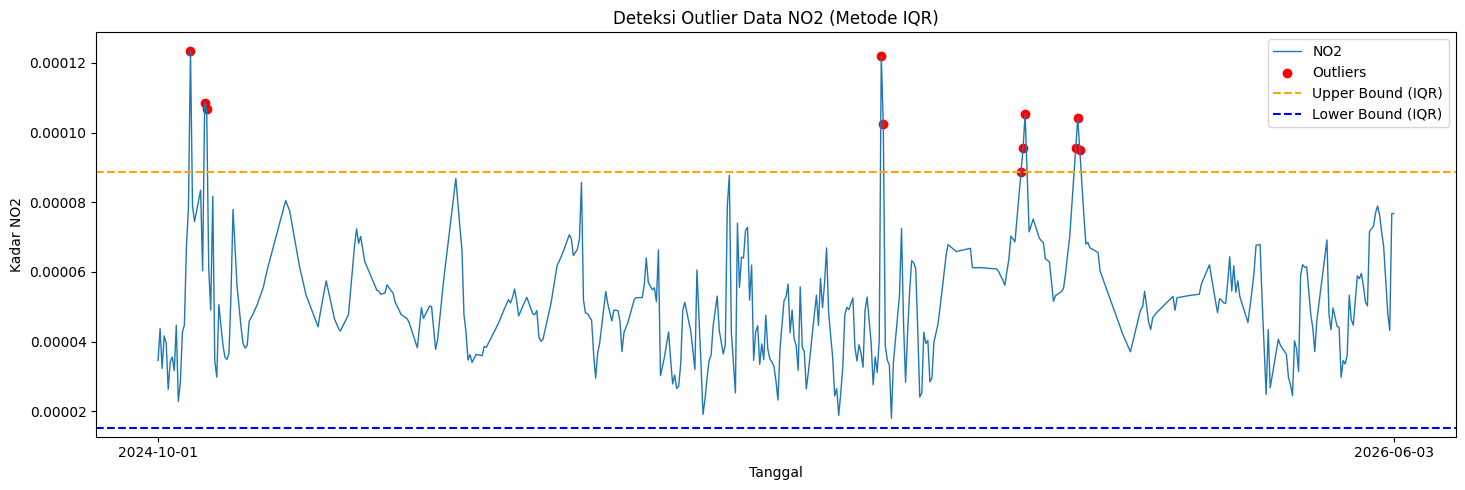

In [18]:
# === Visualisasi ===
plt.figure(figsize=(15,5))
plt.plot(df['date'], df['NO2'], label="NO2", linewidth=1)

# Titik Outlier
plt.scatter(outliers_iqr['date'], outliers_iqr['NO2'],
            color='red', marker='o', label="Outliers")

# Garis batas atas & bawah
plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue', linestyle='dashed', label="Lower Bound (IQR)")

plt.title("Deteksi Outlier Data NO2 (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()

Setelah itu, kita akan menghapus data outlier. Karena data ini merupakan data Time Series, maka data outlier yang dihapus akan diisi kembali menggunakan Interpolasi Linear.


In [19]:
# Tandai outlier menjadi NaN
df['NO2_cleaned'] = df['NO2'].mask((df['NO2'] < lower_bound) | (df['NO2'] > upper_bound))

print("Jumlah nilai yang dinyatakan sebagai outlier:", df['NO2_cleaned'].isna().sum())

# Interpolasi linear untuk mengisi kembali nilai outlier
df['NO2_filled'] = df['NO2_cleaned'].interpolate(method='linear')

# Jika masih tersisa NaN di ujung data, isi dengan forward/backward fill
df['NO2_filled'] = df['NO2_filled'].bfill()
df['NO2_filled'] = df['NO2_filled'].ffill()

print("Jumlah missing setelah interpolasi:", df['NO2_filled'].isna().sum())

Jumlah nilai yang dinyatakan sebagai outlier: 11
Jumlah missing setelah interpolasi: 0


Visualisasi data setelah menghapus outlier dan mengisi kembali menggunakan Interpolasi Linear:


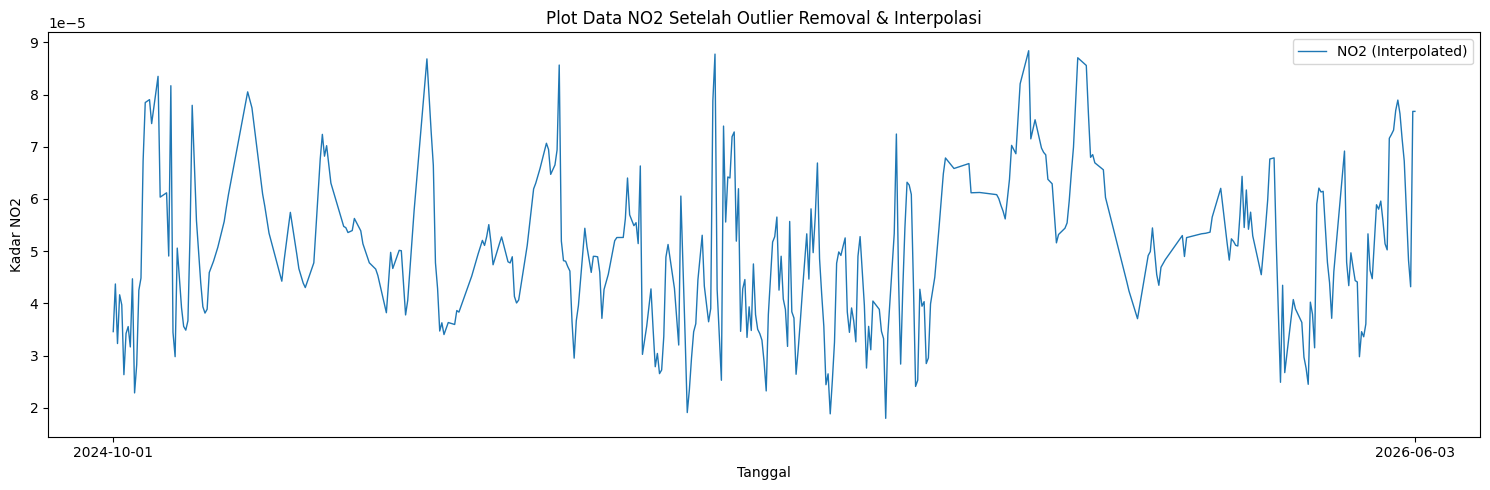

In [20]:
plt.figure(figsize=(15,5))

# Plot data hasil interpolasi
plt.plot(df['date'], df['NO2_filled'], label="NO2 (Interpolated)", linewidth=1)

# Tampilkan hanya tanggal awal dan akhir di sumbu X
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)

plt.title("Plot Data NO2 Setelah Outlier Removal & Interpolasi")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.show()

## 3. Modelling

Dengan data Time Series kadar NO₂ harian di daerah Surabaya, kita akan memprediksi kadar NO₂ satu hari yang akan datang. Sekarang kita ubah data dan mencoba mencari korelasi antara 1 hari dengan beberapa hari sebelumnya.

### a. Uji Korelasi


In [21]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

def create_supervised(data, n_lag=4):
    df_supervised = pd.DataFrame()

    # Membuat fitur t-n sampai t-1
    for i in range(n_lag, 0, -1):
        df_supervised[f'NO2(t-{i})'] = data.shift(i)

    # Label hari H
    df_supervised['NO2(t)'] = data

    # Hapus baris yang masih mengandung NaN akibat shift
    df_supervised.dropna(inplace=True)
    return df_supervised

# Scale the NO2_filled data
scaler = StandardScaler()
df['NO2_scaled'] = scaler.fit_transform(df['NO2_filled'].values.reshape(-1, 1))

# Contoh penggunaan
supervised_df30 = create_supervised(df['NO2_scaled'], n_lag=30)

# Ambil semua lag dan kolom target
lag_cols = supervised_df30.drop(columns="NO2(t)").columns
correlations = supervised_df30[lag_cols].corrwith(supervised_df30['NO2(t)'])

# Tampilkan nilai korelasi
print(correlations)

NO2(t-30)    0.147155
NO2(t-29)    0.154828
NO2(t-28)    0.143788
NO2(t-27)    0.145435
NO2(t-26)    0.134820
NO2(t-25)    0.132559
NO2(t-24)    0.138725
NO2(t-23)    0.129357
NO2(t-22)    0.131368
NO2(t-21)    0.105099
NO2(t-20)    0.072178
NO2(t-19)    0.050306
NO2(t-18)    0.038093
NO2(t-17)    0.051215
NO2(t-16)    0.084309
NO2(t-15)    0.098854
NO2(t-14)    0.107276
NO2(t-13)    0.109647
NO2(t-12)    0.131462
NO2(t-11)    0.161628
NO2(t-10)    0.192061
NO2(t-9)     0.219014
NO2(t-8)     0.263203
NO2(t-7)     0.321875
NO2(t-6)     0.367093
NO2(t-5)     0.432790
NO2(t-4)     0.497611
NO2(t-3)     0.572898
NO2(t-2)     0.697533
NO2(t-1)     0.840805
dtype: float64


### b. Normalisasi Data

Menggunakan Min-Max Scaler.


In [22]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

scaler = MinMaxScaler()

df['NO2_scaled'] = scaler.fit_transform(df[['NO2']])

### c. Mengubah Data

Sekarang kita mengubah data dari sebelumnya hanya 2 fitur menjadi 4 hari sebelum yang terdapat 5 fitur, yaitu `t-4`, `t-3`, `t-2`, `t-1`, dan `t` sebagai label. Kita juga membuat data 10 hari sebelum untuk membandingkan apakah semakin banyak hari sebelumnya, semakin baik pula modelnya.


In [23]:
supervised_df = create_supervised(df['NO2_scaled'], n_lag=4)

print(supervised_df)
print(supervised_df.shape)

     NO2(t-4)  NO2(t-3)  NO2(t-2)  NO2(t-1)    NO2(t)
4    0.157425  0.243927  0.135787  0.224283  0.205957
5    0.243927  0.135787  0.224283  0.205957  0.079267
6    0.135787  0.224283  0.205957  0.079267  0.154011
7    0.224283  0.205957  0.079267  0.154011  0.166610
8    0.205957  0.079267  0.154011  0.166610  0.129627
..        ...       ...       ...       ...       ...
606  0.577750  0.552907  0.507404  0.467006  0.377055
607  0.552907  0.507404  0.467006  0.377055  0.287105
608  0.507404  0.467006  0.377055  0.287105  0.238885
609  0.467006  0.377055  0.287105  0.238885  0.557230
610  0.377055  0.287105  0.238885  0.557230  0.557230

[607 rows x 5 columns]
(607, 5)


Untuk membuat data 10 hari sebelum, tinggal tambah code di bawah dengan mengubah parameter `n_lag`.


In [24]:
supervised_df10 = create_supervised(df['NO2_scaled'], n_lag=10)

print(supervised_df10)
print(supervised_df10.shape)

     NO2(t-10)  NO2(t-9)  NO2(t-8)  NO2(t-7)  NO2(t-6)  NO2(t-5)  NO2(t-4)  \
10    0.157425  0.243927  0.135787  0.224283  0.205957  0.079267  0.154011   
11    0.243927  0.135787  0.224283  0.205957  0.079267  0.154011  0.166610   
12    0.135787  0.224283  0.205957  0.079267  0.154011  0.166610  0.129627   
13    0.224283  0.205957  0.079267  0.154011  0.166610  0.129627  0.253310   
14    0.205957  0.079267  0.154011  0.166610  0.129627  0.253310  0.046168   
..         ...       ...       ...       ...       ...       ...       ...   
606   0.316926  0.305825  0.508396  0.515345  0.523238  0.558905  0.577750   
607   0.305825  0.508396  0.515345  0.523238  0.558905  0.577750  0.552907   
608   0.508396  0.515345  0.523238  0.558905  0.577750  0.552907  0.507404   
609   0.515345  0.523238  0.558905  0.577750  0.552907  0.507404  0.467006   
610   0.523238  0.558905  0.577750  0.552907  0.507404  0.467006  0.377055   

     NO2(t-3)  NO2(t-2)  NO2(t-1)    NO2(t)  
10   0.166610  0.

### d. Modelling


In [25]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

def MAPE(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)

    # Hindari pembagian dengan nol
    nonzero = y_true != 0
    return np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100

def train_knn(df_supervised, model_name=""):
    # Pisahkan fitur & label
    X = df_supervised.drop(columns=['NO2(t)']).values
    y = df_supervised['NO2(t)'].values

    # Split data 80/20
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=False
    )

    # Model KNN
    knn = KNeighborsRegressor(n_neighbors=5)
    knn.fit(X_train, y_train)

    # Prediksi
    y_pred = knn.predict(X_test)

    # Evaluasi
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    mape = MAPE(y_test, y_pred)

    print(f"\n=== {model_name} ===")
    print(f"Train Size: {len(X_train)} — Test Size: {len(X_test)}")
    print(f"RMSE: {rmse:.6f}")
    print(f"R² Score: {r2:.4f}")
    print(f"MAPE: {mape:.4f}%")

    return knn, y_test, y_pred

# Train model untuk 4 hari sebelumnya
knn_4, y_test_4, y_pred_4 = train_knn(supervised_df, "KNN - 4 Hari Sebelumnya")

# Train model untuk 10 hari sebelumnya
knn_10, y_test_10, y_pred_10 = train_knn(supervised_df10, "KNN - 10 Hari Sebelumnya")


=== KNN - 4 Hari Sebelumnya ===
Train Size: 485 — Test Size: 122
RMSE: 0.083449
R² Score: 0.4160
MAPE: 24.0722%

=== KNN - 10 Hari Sebelumnya ===
Train Size: 480 — Test Size: 121
RMSE: 0.084216
R² Score: 0.4088
MAPE: 26.9373%


### e. Plotting

Plotting untuk visualisasi grafik antara label dan prediksi dari kedua data di atas.

4 hari sebelum:


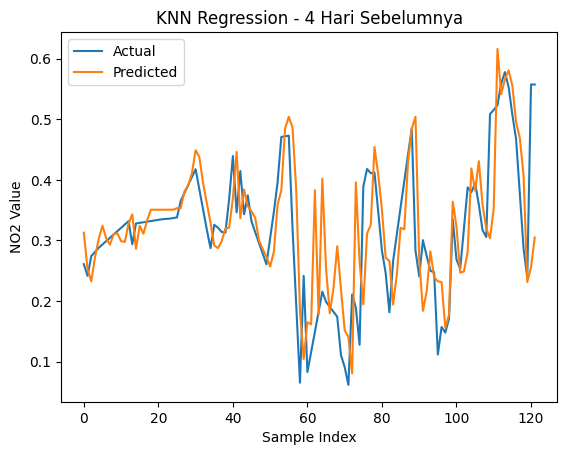

In [26]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure()
plt.plot(np.arange(len(y_test_4)), y_test_4, label="Actual")
plt.plot(np.arange(len(y_pred_4)), y_pred_4, label="Predicted")
plt.title("KNN Regression - 4 Hari Sebelumnya")
plt.xlabel("Sample Index")
plt.ylabel("NO2 Value")
plt.legend()
plt.show()

10 hari sebelum:


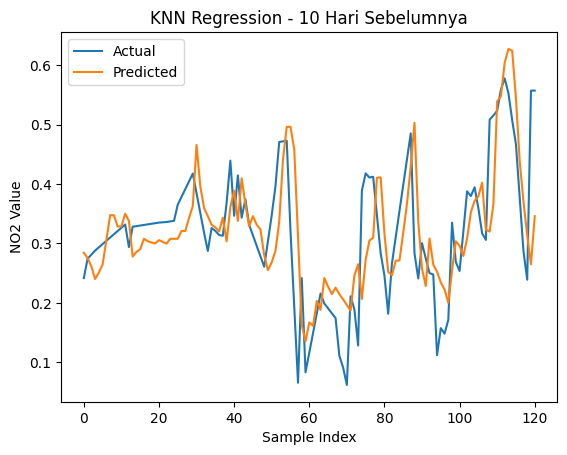

In [27]:
plt.figure()
plt.plot(np.arange(len(y_test_10)), y_test_10, label="Actual")
plt.plot(np.arange(len(y_pred_10)), y_pred_10, label="Predicted")
plt.title("KNN Regression - 10 Hari Sebelumnya")
plt.xlabel("Sample Index")
plt.ylabel("NO2 Value")
plt.legend()
plt.show()

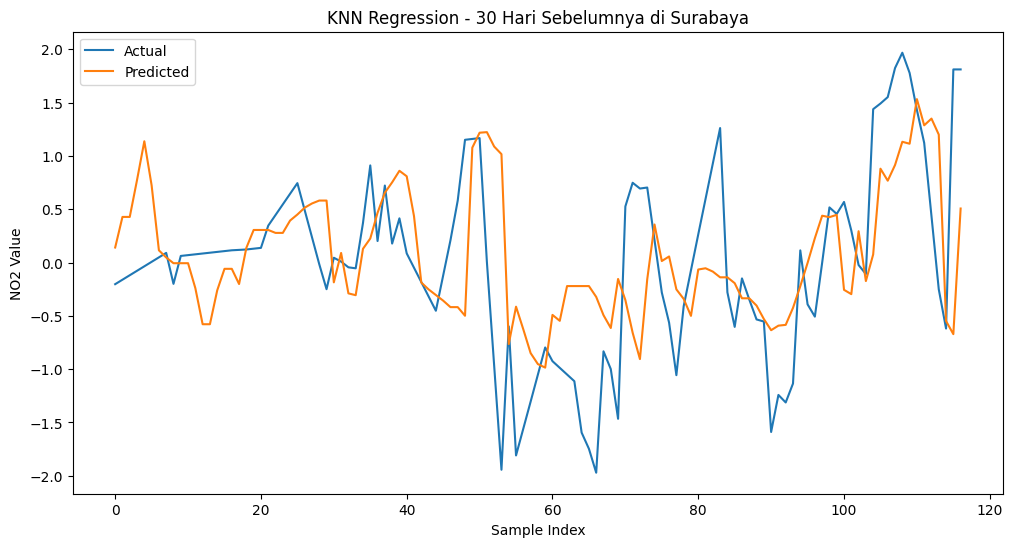

In [39]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 6))
plt.plot(np.arange(len(y_test_30)), y_test_30, label="Actual")
plt.plot(np.arange(len(y_pred_30)), y_pred_30, label="Predicted")
plt.title("KNN Regression - 30 Hari Sebelumnya di Surabaya")
plt.xlabel("Sample Index")
plt.ylabel("NO2 Value")
plt.legend()
plt.show()

### Analisis Hasil Evaluasi Model KNN Regression

Hasil evaluasi model KNN Regression menunjukkan bahwa penggunaan data historis atau lag berpengaruh terhadap performa prediksi kadar NO₂. Pada model dengan 4 hari sebelumnya, hasil prediksi masih menunjukkan performa yang lebih baik dibandingkan model dengan jumlah lag yang lebih besar. Hal ini dapat dilihat dari nilai error yang lebih kecil serta nilai R² yang masih lebih baik dibandingkan model lainnya.

Namun, ketika jumlah fitur historis ditambah menjadi 10 hari dan 30 hari sebelumnya, performa model cenderung mengalami penurunan. Hal tersebut ditunjukkan oleh meningkatnya nilai error seperti MAE, MSE, RMSE, dan MAPE. Selain itu, nilai R² yang semakin menurun menunjukkan bahwa model semakin kurang mampu menjelaskan pola hubungan antara data historis NO₂ dengan nilai target yang diprediksi.

Pada model 30 hari sebelumnya, hasil prediksi belum mampu mengikuti pola data aktual secara optimal. Garis prediksi masih terlihat memiliki selisih yang cukup besar dengan garis aktual pada beberapa titik data. Hal ini menunjukkan bahwa penambahan jumlah lag tidak selalu membuat model menjadi lebih akurat. Semakin banyak fitur historis yang digunakan, model dapat menjadi terlalu kompleks dan kurang mampu melakukan generalisasi terhadap data testing.

Nilai MAPE yang cukup tinggi juga mengindikasikan bahwa tingkat kesalahan prediksi masih besar. Dengan demikian, akurasi model KNN Regression pada data NO₂ ini masih tergolong kurang baik. Secara keseluruhan, model KNN belum memberikan hasil prediksi yang optimal, terutama pada penggunaan lag yang lebih panjang seperti 10 hari dan 30 hari sebelumnya.

Berdasarkan hasil tersebut, dapat disimpulkan bahwa model dengan 4 hari sebelumnya lebih baik dibandingkan model dengan 10 hari dan 30 hari sebelumnya. Akan tetapi, performa model secara umum masih perlu ditingkatkan. Oleh karena itu, diperlukan perbaikan pada tahap preprocessing data, pemilihan parameter KNN, atau penggunaan metode peramalan lain agar hasil prediksi kadar NO₂ menjadi lebih akurat.